In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

# Deep Neural Networks 
## Session 07a

## Introduction to Tensorflow 
- Tensorflow
- Wines Dataset

<img src='../../prasami_images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com"/>

In [61]:
###-----------------
### Import Libraries
###-----------------

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, 
                             ConfusionMatrixDisplay, f1_score)

import tensorflow as tf

In [3]:
RANDOM_STATE = 24
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

EPOCHS = 100
TEST_SIZE = 0.2
ALPHA=0.001

## Basic Hygiene

In [4]:
### Settings so that Tensorflow can not Hog all the GPU memory
physical_devices = tf.config.list_physical_devices('GPU') 

if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

## Read wines data from csv

In [5]:
data_df = pd.read_csv('../../input/machine_learning/wine.csv', header=None)
data_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [6]:
data_df.shape

(178, 14)

In [7]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       178 non-null    float64
 1   1       178 non-null    float64
 2   2       178 non-null    float64
 3   3       178 non-null    float64
 4   4       178 non-null    int64  
 5   5       178 non-null    float64
 6   6       178 non-null    float64
 7   7       178 non-null    float64
 8   8       178 non-null    float64
 9   9       178 non-null    float64
 10  10      178 non-null    float64
 11  11      178 non-null    float64
 12  12      178 non-null    int64  
 13  13      178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [8]:
# Are there NaNs Still?

data_df.isna().sum()

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
dtype: int64

In [9]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
0,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
1,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
2,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
3,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
4,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
5,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
6,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
7,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
8,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
9,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


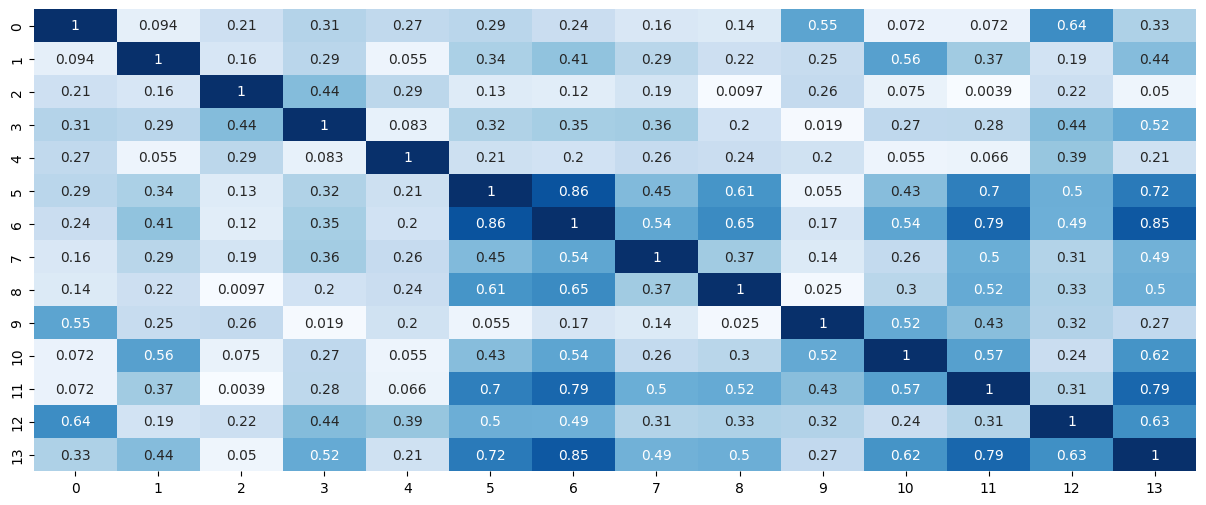

In [10]:
fig, ax = plt.subplots(figsize=(15,6))
sns.heatmap(data_df.corr().abs(), ax = ax,
            cmap= 'Blues',
            annot=True, fmt='.2g', 
            cbar = False);


In [11]:
for col in data_df.columns:
    print (f'{col}: {data_df[col].unique()}\n')

0: [14.23 13.2  13.16 14.37 13.24 14.2  14.39 14.06 14.83 13.86 14.1  14.12
 13.75 14.75 14.38 13.63 14.3  13.83 14.19 13.64 12.93 13.71 12.85 13.5
 13.05 13.39 13.3  13.87 14.02 13.73 13.58 13.68 13.76 13.51 13.48 13.28
 13.07 14.22 13.56 13.41 13.88 14.21 13.9  13.94 13.82 13.77 13.74 13.29
 13.72 12.37 12.33 12.64 13.67 12.17 13.11 13.34 12.21 12.29 13.49 12.99
 11.96 11.66 13.03 11.84 12.7  12.   12.72 12.08 12.67 12.16 11.65 11.64
 12.69 11.62 12.47 11.81 12.6  12.34 11.82 12.51 12.42 12.25 12.22 11.61
 11.46 12.52 11.76 11.41 11.03 12.77 11.45 11.56 11.87 12.07 12.43 11.79
 12.04 12.86 12.88 12.81 12.53 12.84 13.36 13.52 13.62 12.87 13.32 13.08
 12.79 13.23 12.58 13.17 13.84 12.45 14.34 12.36 13.69 12.96 13.78 13.45
 12.82 13.4  12.2  14.16 13.27 14.13]

1: [1.71 1.78 2.36 1.95 2.59 1.76 1.87 2.15 1.64 1.35 2.16 1.48 1.73 1.81
 1.92 1.57 1.59 3.1  1.63 3.8  1.86 1.6  2.05 1.77 1.72 1.9  1.68 1.5
 1.66 1.83 1.53 1.8  1.65 3.99 3.84 1.89 3.98 4.04 3.59 2.02 1.75 1.67
 1.7  1.97 1.4

In [12]:
labels = data_df[data_df.columns[-1]]
features_df = data_df.drop(data_df.columns[-1], axis =1)
assert features_df.shape[0] == labels.shape[0], 'Number of examples not same'

In [13]:
#  Split the data in training and test sets to measure performance of the model.
X_train, X_test, y_train, y_test = train_test_split(features_df, labels, 
                                                    test_size=TEST_SIZE,
                                                    stratify=labels,
                                                    random_state=RANDOM_STATE )

print (X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(142, 13) (142,) (36, 13) (36,)


In [14]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)

In [15]:
le = LabelEncoder() # convert 1, 2, 3 -> 0, 1, 2
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

## Prepare model

Build the `tf.keras.Sequential` model by stacking layers. Choose an optimizer and loss function for training:

In [16]:
# nodes : 13, 8, 3

model = tf.keras.Sequential([
    tf.keras.Input(shape = (X_train.shape[1],)),

    tf.keras.layers.Dense(8, activation='relu'),

    tf.keras.layers.Dense(3)
])

I0000 00:00:1777988667.109726   22615 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3694 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## Reference
<p style="font-family: Arial; font-size:1.2em;">
Details of <a href = "https://www.tensorflow.org/api_docs/python/tf/keras/Sequential">Sequential Model</a>. Sequential provides training and predict features on this model.
</p>

### Functional API

<p style="font-family: Arial; font-size:1.2em;">You can also instantiate a Model with the <strong>"Functional API"</strong>, where you start from Input, you chain layer calls to specify the model's forward pass, and finally you create your model from inputs and outputs:

    
<p style="font-family: Arial; font-size:1.2em;">You can also extend the model class, if love to live by sword!!
</p>

In [17]:
inputs = tf.keras.Input(shape = (X_train.shape[1],))
    
x = tf.keras.layers.Dense(8, activation=tf.nn.relu)(inputs)

outputs = tf.keras.layers.Dense(3)(x)

model1 = tf.keras.Model(inputs=inputs, outputs=outputs)

<p style="font-family: Arial; font-size:1.2em;">
    For each example the model returns a vector of "logits" or "log-odds" scores, one for each class.
</p>

In [18]:
X_train[:1].shape

(1, 13)

In [19]:
X_train[:1]

array([[-0.02222104, -0.61751924,  0.85197806,  3.13822833,  2.89556415,
         1.63549206,  0.86441875, -1.2103246 ,  0.59041704, -0.74138556,
         1.52983005,  1.27292302,  0.73966546]])

In [20]:
predictions = model(X_train[:1]).numpy()
predictions

array([[-1.0059849, -1.0722544, -3.1108017]], dtype=float32)

In [21]:
predictions.sum()

np.float32(-5.189041)

The `tf.nn.softmax` function converts these logits to "probabilities" for each class: 

In [22]:
tf.nn.softmax(predictions).numpy()

array([[0.48596847, 0.45480752, 0.059224  ]], dtype=float32)

In [23]:
tf.nn.softmax(predictions).numpy().sum()

np.float32(1.0)

In [24]:
'''
Number of parameters:
    layer 1 : 13*8 + 8 = 112 
    layer 2 : 8*3 + 3 = 27
We are not locking any layer hence all parameter are trainable    
'''

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139 (556.00 B)

 Trainable params: 139 (556.00 B)

 Non-trainable params: 0 (0.00 B)

## Is Model 1 similar??

In [25]:
pred1 = model1(X_train[:1]).numpy()

In [26]:
model1.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139 (556.00 B)

 Trainable params: 139 (556.00 B)

 Non-trainable params: 0 (0.00 B)

## Game Changer

`Softmax` function is prone to two issues: overflow and underflow.

- <b>Overflow</b> occurs when very large numbers are being fed.
- <b>Underflow</b> occurs when very small numbers (near zero) are being fed.

There are work arounds too, but, TF has its own approach.<br>
    
Intuition being that every system (32 / 64 bit precision) has limits in terms of largest or smallest value it can accurately process.

It also leads to the vanishing gradient in exponential functions. As you go higher/lower the  value will overflow and the gradient will be `zero` irrespective of actually it being a `non-zero`.


Our loss function is crossentropy as there are two or more label classes. The labels are provided using one-hot representation. We will use CategoricalCrossentropy loss. 
    
>y_true = [ [0      1    0], [ 0    1   0 ]<br>
>y_pred = [ [0.05, 0.95, 0], [0.1, 0.1, 0.8] ]


In case, you have not one-hot-encoded use `losses.SparseCategoricalCrossentropy`. It takes a vector of logits and a `True` index and returns a scalar loss for each example.

In [27]:
sys.float_info.max

1.7976931348623157e+308

In [28]:
sys.float_info.min

2.2250738585072014e-308

In [29]:
np.log(sys.float_info.max)

np.float64(709.782712893384)

In [30]:
np.exp(709)

np.float64(8.218407461554972e+307)

Using from_logits=True is more numerically stable than applying softmax then crossentropy separately because it combines operations and avoids intermediate log(softmax(x)) calculations.

#### BAD (numerically unstable):
> model_with_softmax = tf.keras.Sequential([... tf.keras.layers.Softmax()])
> loss = tf.keras.losses.CategoricalCrossentropy()

####GOOD (numerically stable):
> model_with_logits = tf.keras.Sequential([...])  # No softmax layer
> loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [ ]:
# Loss function
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy ( from_logits = True)

In [32]:
y_train[:1]

array([1])

In [33]:
loss_fn(y_train[:1], predictions).numpy()

np.float32(0.787881)

Using `model.compile`, specify the training configuration such as:
- Loss function to minimize
- Optimizer
- List of metrics to monitor

In [34]:
# Step 2: Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA)

In [35]:
# Step 3: Compile
model.compile(optimizer=optimizer,
              loss=loss_fn,
              metrics=['accuracy'])

Call `fit()`, which will train the model by slicing the data into `batches` of size `batch_size`, and repeatedly iterating over the entire dataset for a given number of `epochs`. Pass some validation for monitoring validation loss and metrics at the end of each epoch.

In [36]:
history = model.fit(X_train, y_train, 
                    validation_data=[X_test, y_test],
                    epochs=EPOCHS)

Epoch 1/100


I0000 00:00:1777988696.279028   22804 service.cc:153] XLA service 0x7996d8033990 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777988696.279052   22804 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1777988696.295881   22804 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777988696.392782   22804 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1777988696.398708   22804 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1005__.10


1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3125 - loss: 1.5138

I0000 00:00:1777988697.732032   22804 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1777988697.843809   22801 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1005__.10


5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 515ms/step - accuracy: 0.3732 - loss: 1.4564 - val_accuracy: 0.4444 - val_loss: 1.4350
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4014 - loss: 1.4088 - val_accuracy: 0.4722 - val_loss: 1.3853
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4366 - loss: 1.3633 - val_accuracy: 0.4722 - val_loss: 1.3371
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4507 - loss: 1.3192 - val_accuracy: 0.5000 - val_loss: 1.2907
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4718 - loss: 1.2762 - val_accuracy: 0.5000 - val_loss: 1.2455
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4930 - loss: 1.2345 - val_accuracy: 0.5000 - val_loss: 1.2017
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5141 - loss: 1.1944 - val_accuracy: 0.5000 - val_loss: 1.1595
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5282 - loss: 1.1555 - val_accuracy: 0.5000 - val_loss: 1.1188
Epo

In case we want to separately evaluate this model, we have `evaluate` function.

In [37]:
model.evaluate ( X_test,  y_test, verbose=2)

2/2 - 0s - 20ms/step - accuracy: 0.9444 - loss: 0.0996


[0.09961012005805969, 0.9444444179534912]

In [38]:
loss_df = pd.DataFrame(history.history)
loss_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.373239,1.456400,0.444444,1.435029
1,0.401408,1.408756,0.472222,1.385267
2,0.436620,1.363293,0.472222,1.337116
3,0.450704,1.319185,0.500000,1.290674
4,0.471831,1.276227,0.500000,1.245478


In [ ]:
y_pred = model.predict(X_test)
accuracy_score = accuracy_score(y_test, y_pred.argmax(axis=1))
print(accuracy_score)loss_df.iloc[-1][loss_df.columns[1]]

np.float64(0.0880039781332016)

In [1]:
###-----------------------------------------------------------
### Function to plot Loss Curve using Tensorflow history object
###------------------------------------------------------------

def fn_plot_tf_hist(hist_df):
    
    '''
    Args:
        hist_df: a DataFrame with column names accuracy,loss	val_accuracy	val_loss
    '''
        
    fig, axes = plt.subplots(1,2 , figsize = (15,6))

    # properties  matplotlib.patch.Patch 
    props = dict(boxstyle='round', facecolor='aqua', alpha=0.4)
    facecolor = 'cyan'
    fontsize=12
    CMAP = plt.cm.coolwarm
    
    # Get columns by index to eliminate any column naming error
    y1 = hist_df.columns[0]
    y2 = hist_df.columns[1]
    y3 = hist_df.columns[2]
    y4 = hist_df.columns[3]

    # Where was min loss
    best = hist_df[hist_df[y4] == hist_df[y4].min()]
    
    ax = axes[0]

    hist_df.plot(y = [y2,y4], ax = ax, colormap=CMAP)


    # little beautification
    txtFmt = "Loss: \n  train: {:6.4f}\n   test: {:6.4f}"
    txtstr = txtFmt.format(hist_df.iloc[-1][y2],
                           hist_df.iloc[-1][y4]) #text to plot
    
    # place a text box in upper middle in axes coords
    ax.text(0.3, 0.95, txtstr, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment='top', bbox=props)
    
    # calculate offset for arrow
    y_min = min(hist_df[y2].min(), hist_df[y4].min())
    y_max = max(hist_df[y2].max(), hist_df[y4].max())
    offset = (y_max-y_min)/10.0
    
    best_idx = best.index.to_numpy()[0]  # Extract first (and only) element as scalar
    best_value = best[y4].to_numpy()[0]   # Extract scalar value
    
    # Mark arrow at lowest
    ax.annotate(f'Min: {best_value:6.4f}', # text to print
                xy=(best_idx, best_value), # Arrow start
                xytext=(best_idx, best_value + offset), # location of text 
                fontsize=fontsize, va='bottom', ha='right',bbox=props, # beautification of text
                arrowprops=dict(facecolor=facecolor, shrink=0.05)) # arrow
    
    # Draw vertical line at best value
    ax.axvline(x = best_idx, color = 'green', linestyle='-.', lw = 3)

    ax.set_xlabel("Epochs")
    ax.set_ylabel(y2.capitalize())
    ax.set_title('Loss Curve')
    ax.grid(True)
    ax.legend(loc = 'upper left') # model legend to upper left
    
    ax = axes[1]

    hist_df.plot( y = [y1, y3], ax = ax, colormap=CMAP)
    
    # little beautification
    txtFmt = "Accuracy: \n  train: {:6.4f}\n  test:  {:6.4f}"
    txtstr = txtFmt.format(hist_df.iloc[-1][y1],
                           hist_df.iloc[-1][y3]) #text to plot

    # place a text box in upper middle in axes coords
    ax.text(0.3, 0.2, txtstr, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment='top', bbox=props)

    # calculate offset for arroe
    y_min = min(hist_df[y1].min(), hist_df[y3].min())
    y_max = max(hist_df[y1].max(), hist_df[y3].max())
    offset = (y_max-y_min)/10.0

    best_value = best[y3].to_numpy()[0]   # Extract scalar value
    # Mark arrow at lowest
    ax.annotate(f'Best: {best_value:6.4f}', # text to print
                xy=(best_idx, best_value), # Arrow start
                xytext=(best_idx, best_value-offset), # location of text 
                fontsize=fontsize, va='bottom', ha='right',bbox=props, # beautification of text
                arrowprops=dict(facecolor=facecolor, shrink=0.05)) # arrow
    
    
    # Draw vertical line at best value
    ax.axvline(x = best_idx, color = 'green', linestyle='-.', lw = 3)

    ax.set_xlabel("Epochs")
    ax.set_ylabel(y1.capitalize())
    ax.set_title('Accuracy Curve')
    ax.grid(True)
    ax.legend(loc = 'lower left')
    
    plt.tight_layout()
    


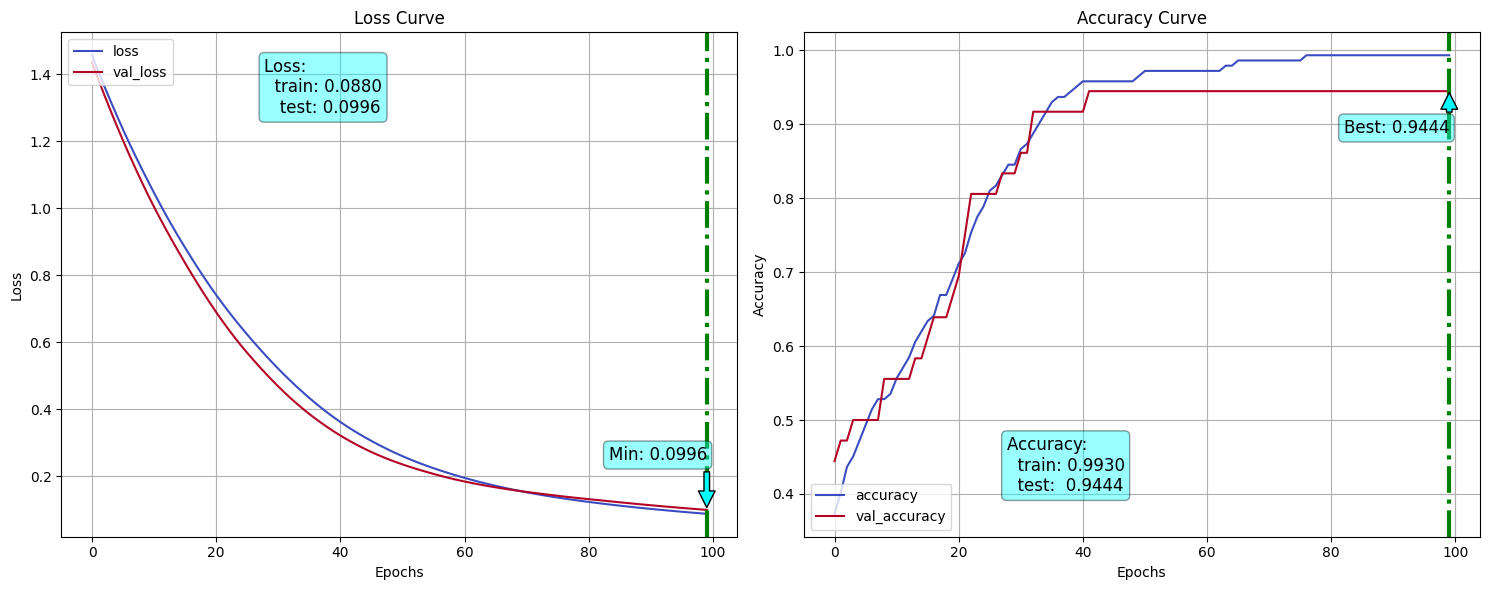

In [41]:
fn_plot_tf_hist(loss_df)

In [42]:
loss_df[loss_df['val_loss'] == loss_df['val_loss'].min()]

,accuracy,loss,val_accuracy,val_loss
99,0.992958,0.088004,0.944444,0.09961


## Predictions

In [43]:
probability_model = tf.keras.Sequential([
  model,
  tf.keras.layers.Softmax()
])

In [63]:
y_pred = probability_model(X_train).numpy()
y_pred.shape

(142, 3)

In [64]:
accuracy_score(y_train, y_pred.argmax(axis=1))

0.9929577464788732

In [45]:
print(classification_report( y_train, y_pred.argmax( axis = 1)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      0.98      0.99        57
           2       0.97      1.00      0.99        38

    accuracy                           0.99       142
   macro avg       0.99      0.99      0.99       142
weighted avg       0.99      0.99      0.99       142



In [67]:
y_pred = probability_model(X_test).numpy()

print('Accuracy score on Test Data :{:.5f}'.format(accuracy_score(y_test, 
                                                                  np.argmax(y_pred, axis = 1))))

Accuracy score on Test Data :0.94444


In [68]:
print(classification_report(y_test, 
                            np.argmax(y_pred, axis = 1)))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.86      0.92        14
           2       0.91      1.00      0.95        10

    accuracy                           0.94        36
   macro avg       0.94      0.95      0.95        36
weighted avg       0.95      0.94      0.94        36



In [69]:
def fn_plot_confusion_matrix(y_true, y_pred, labels):
    '''
    Args:
        y_true: Ground Truth 
        y_pred : Predictions
        labels : dictonary
    
    '''
    
    cm  = confusion_matrix(y_true, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels.values())
    
    fig, ax = plt.subplots(figsize = (4,4))
    
    disp.plot(ax = ax, cmap = 'Blues', xticks_rotation = 'vertical', colorbar=False)
    # Disable the grid
    ax.grid(False)
    ax.set_title(f"F1_Score: {f1_score(y_test,y_pred, average='weighted'):0.4f}")
    plt.show()

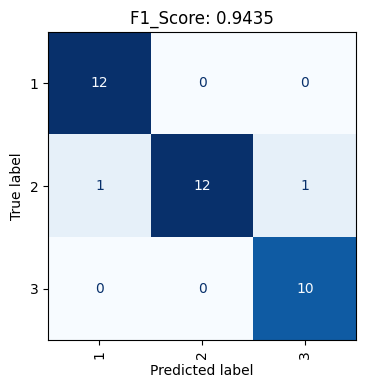

In [70]:
class_labels = {0: 1, 1:2, 2:3}
fn_plot_confusion_matrix( y_test, y_pred.argmax( axis = 1), labels=class_labels)